<a href="https://colab.research.google.com/github/jessisam2007/24BAD049_24ADI006-DeepLearning/blob/main/24BAD049_DL_EX3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 3: Implementation of Convolutional Neural Networks (CNNs) for Image Classification

**Aim:** To design, implement, and evaluate a Convolutional Neural Network (CNN) for image classification using a benchmark image dataset.

**Dataset used:** CIFAR-10 (benchmark dataset, loaded directly via `tensorflow.keras.datasets` — no external download needed, works out-of-the-box in Colab).



## Task A: Dataset Preparation



24BAD049 - JESSICA SAM B
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2004s 12us/step
Full training data shape : (50000, 32, 32, 3)
Full training labels shape: (50000, 1)
Test data shape          : (10000, 32, 32, 3)
Test labels shape        : (10000, 1)

After splitting:
Training samples  : 45000
Validation samples: 5000
Testing samples   : 10000


/tmp/ipykernel_456/450232533.py:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train_full[num_val + i])])


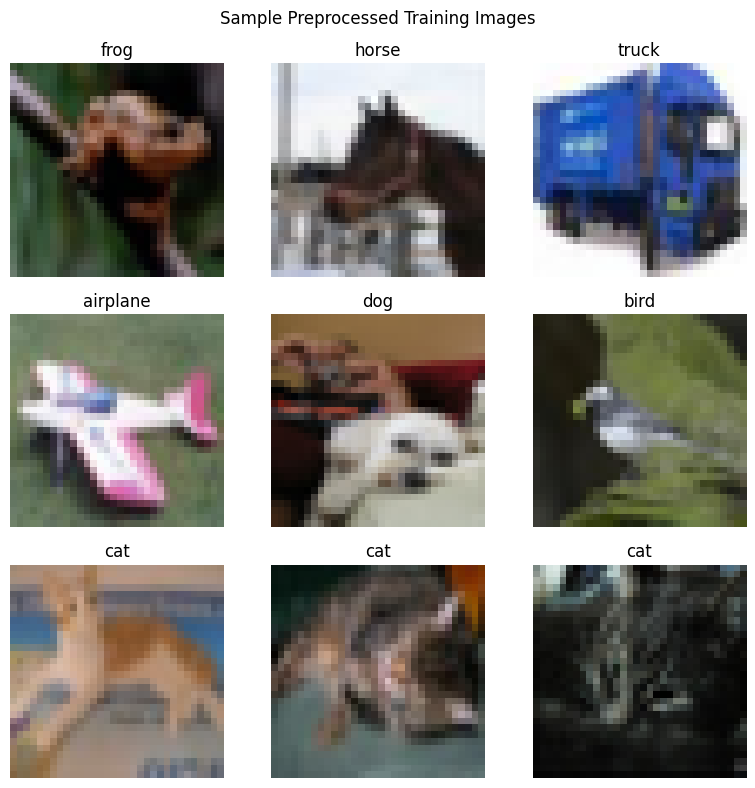

In [ ]:
print("24BAD049 - JESSICA SAM B")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Full training data shape :", x_train_full.shape)
print("Full training labels shape:", y_train_full.shape)
print("Test data shape          :", x_test.shape)
print("Test labels shape        :", y_test.shape)

IMG_SIZE = 32
x_train_full = tf.image.resize(x_train_full, [IMG_SIZE, IMG_SIZE]).numpy()
x_test = tf.image.resize(x_test, [IMG_SIZE, IMG_SIZE]).numpy()

x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train_full_cat = to_categorical(y_train_full, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

val_split = 0.1
num_val = int(len(x_train_full) * val_split)

x_val = x_train_full[:num_val]
y_val = y_train_full_cat[:num_val]

x_train = x_train_full[num_val:]
y_train = y_train_full_cat[num_val:]

print("\nAfter splitting:")
print("Training samples  :", x_train.shape[0])
print("Validation samples:", x_val.shape[0])
print("Testing samples   :", x_test.shape[0])

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train_full[num_val + i])])
    plt.axis('off')
plt.suptitle("Sample Preprocessed Training Images")
plt.tight_layout()
plt.show()


## Task B: CNN Model Implementation




In [ ]:
print("24BAD049 - JESSICA SAM B")

from tensorflow.keras import layers, models

model = models.Sequential(name="CNN_Image_Classifier")

model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                         input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


24BAD049 - JESSICA SAM B


Model: "CNN_Image_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## Task C: Model Training and Evaluation




24BAD049 - JESSICA SAM B
Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 116s 160ms/step - accuracy: 0.3900 - loss: 1.6582 - val_accuracy: 0.5288 - val_loss: 1.3250
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 110s 157ms/step - accuracy: 0.5370 - loss: 1.2960 - val_accuracy: 0.6266 - val_loss: 1.0799
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 156ms/step - accuracy: 0.6020 - loss: 1.1196 - val_accuracy: 0.6568 - val_loss: 0.9606
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 112s 159ms/step - accuracy: 0.6467 - loss: 1.0058 - val_accuracy: 0.7008 - val_loss: 0.8614
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 158ms/step - accuracy: 0.6791 - loss: 0.9142 - val_accuracy: 0.6914 - val_loss: 0.8816
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 157ms/step - accuracy: 0.7094 - loss: 0.8325 - val_accuracy: 0.7128 - val_loss: 0.8124
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 161ms/step - accuracy: 0.7282 - loss: 0.7756 - val_accuracy: 0.7324 - val_loss: 0.7635
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 115s 163ms/

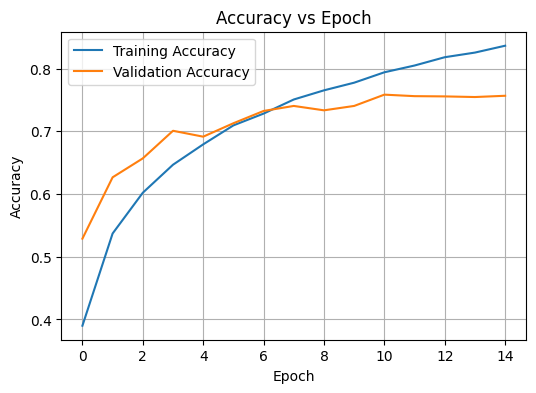

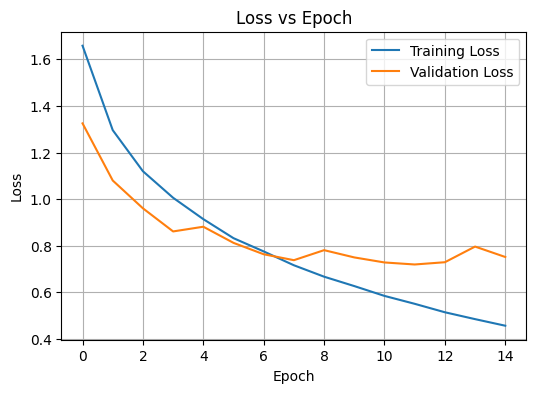

In [ ]:
print("24BAD049 - JESSICA SAM B")

EPOCHS = 15
BATCH_SIZE = 64

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy   : {train_acc:.4f}")
print(f"Final Validation Accuracy : {val_acc:.4f}")
print(f"Final Training Loss       : {train_loss:.4f}")
print(f"Final Validation Loss     : {val_loss:.4f}")

test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Testing Accuracy          : {test_acc:.4f}")
print(f"Testing Loss              : {test_loss:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


## Task D: Performance Analysis



24BAD049 - JESSICA SAM B
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step
Classification Accuracy on Test Set: 0.7499

Classification Report:

              precision    recall  f1-score   support

    airplane       0.83      0.75      0.79      1000
  automobile       0.88      0.85      0.87      1000
        bird       0.62      0.67      0.64      1000
         cat       0.52      0.61      0.56      1000
        deer       0.69      0.75      0.72      1000
         dog       0.70      0.62      0.66      1000
        frog       0.82      0.79      0.80      1000
       horse       0.83      0.76      0.79      1000
        ship       0.86      0.86      0.86      1000
       truck       0.81      0.84      0.83      1000

    accuracy                           0.75     10000
   macro avg       0.76      0.75      0.75     10000
weighted avg       0.76      0.75      0.75     10000



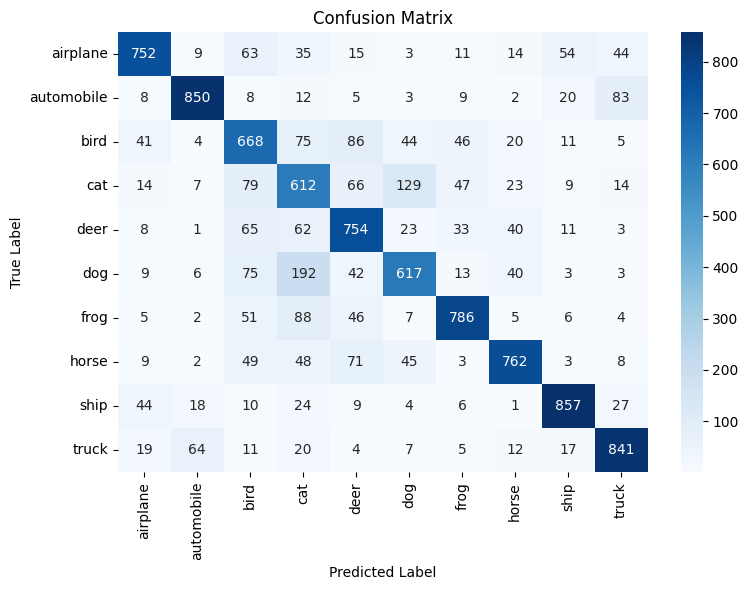

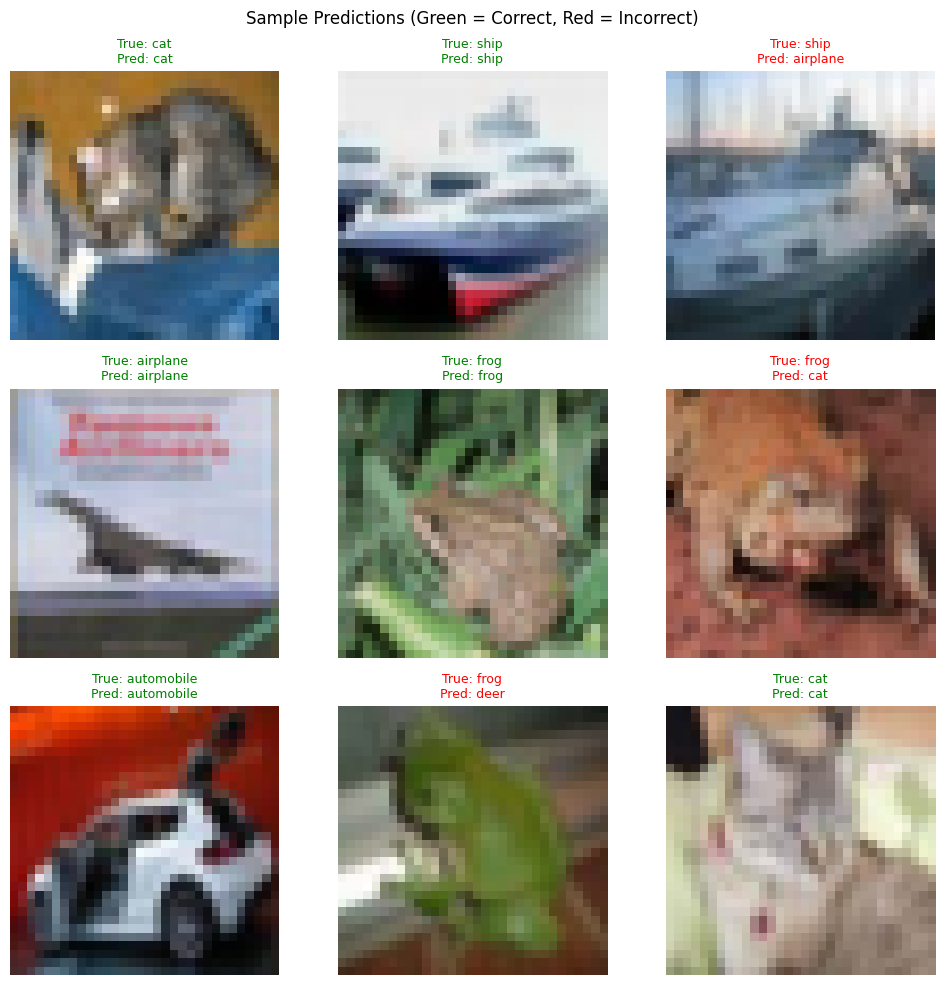

Total misclassified images: 2501 out of 10000


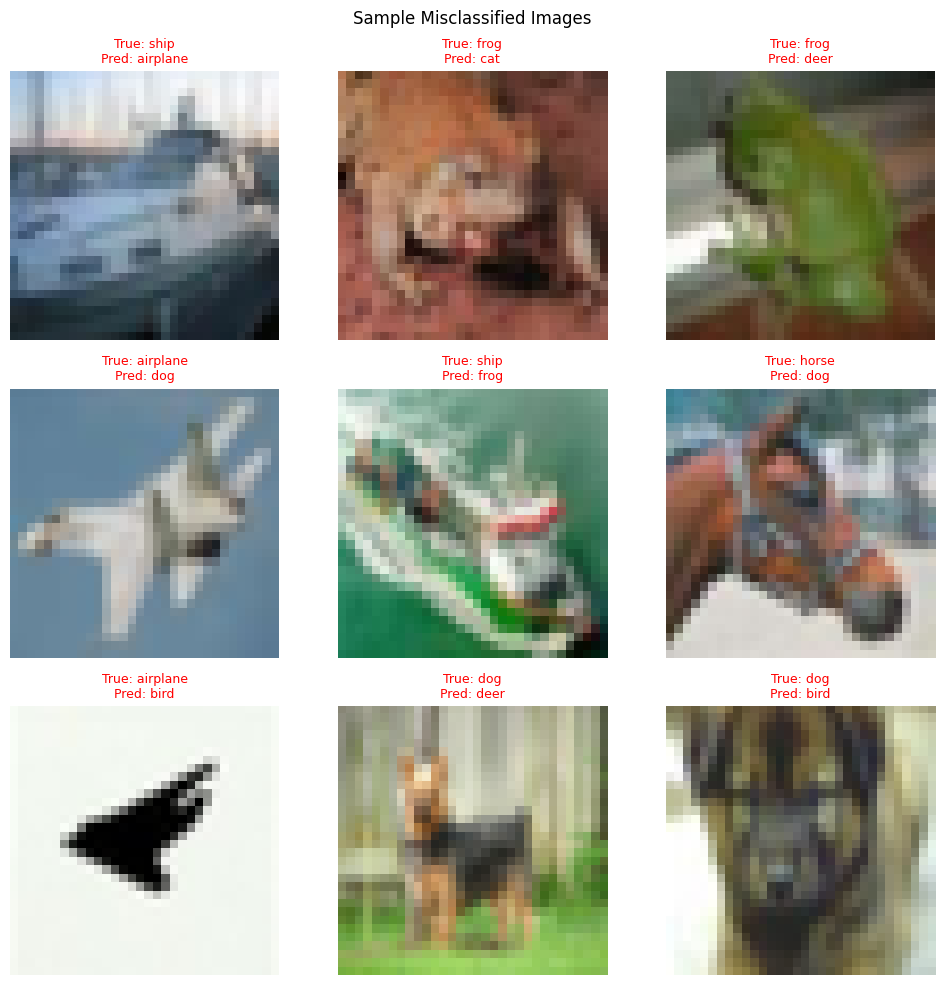

In [ ]:
print("24BAD049 - JESSICA SAM B")

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

final_test_accuracy = np.mean(y_pred == y_true)
print(f"Classification Accuracy on Test Set: {final_test_accuracy:.4f}\n")

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i])
    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred[i]]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)
    plt.axis('off')
plt.suptitle("Sample Predictions (Green = Correct, Red = Incorrect)")
plt.tight_layout()
plt.show()

misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified images: {len(misclassified_idx)} out of {len(y_true)}")

plt.figure(figsize=(10, 10))
for i, idx in enumerate(misclassified_idx[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}",
               color='red', fontsize=9)
    plt.axis('off')
plt.suptitle("Sample Misclassified Images")
plt.tight_layout()
plt.show()
